In [4]:
!pip install torchinfo # do funkcji summary

In [5]:
import numpy as np
import torch
from scipy.signal import convolve2d
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
from google.colab import drive


### Jak zrobić zadanie

Notebook składa się z 4 zadań, jednak **najważniejsze są zadania 3 i 4**, bo dotyczą stricte własnej implementacji sieci konwolucyjnej. W poszczególnych sekcjach znajdują się opisy które powinny wystarczyć do zrozumienia i implementacji, ale poniżej zamieszczone są źródła do dalszej nauki.

Zbiorem danych będzie *FashionMNIST* lub *CIFAR10* (w zależności od waszej preferencji).

Źródła
- https://visionbook.mit.edu/convolutional_neural_nets.html -> na pograniczu CV i CNN
- https://engineering.purdue.edu/DeepLearn/pdf-kak/DemystifyConvo.pdf -> przydatne do zadania z konwolucją
- https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks#layer -> wizualizacje
- https://guandi1995.github.io/Padding/ -> objaśnienie paddingu
- https://cs231n.github.io/convolutional-networks/ -> kurs od stanford
- warstwy w PyTorch: [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [MaxPool2d
](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d), [BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d), [Dropout2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html#torch.nn.Dropout2d)


### 0. Po co nam coś więcej niż MLP?

Na poprzedniej liście spłaszczaliśmy obrazki, aby móc je przepuścić przez sieć FNN, jednak taki preprocessing do formy tabelarycznej gubi istotne informacje. Po pierwsze, piksele blisko siebie w oryginalnym obrazie mogą znaleźć się daleko od siebie, dodatkowo wszystkie piksele będą "wymieniać" się sygnałami z wszystkimi innymi pikselami. Jest to mechanizm dosyć nieefektywny (w szarym obrazku o rozmiarze 128x128 mamy na wejściu już 16 384 cech!) i tu na pomoc przychodzą konwolucje.

### 1. Konwolucja

Podstawową operację konwolucji jest lepiej sobie zobrazować (pun intended) na podstawie jednego, oczywistego przykładu. Załóżmy, że mamy obraz binarny (czyli składający się z 0 i 1). Jest to typowa reprezentacja maski w zadaniu segmentacji - 1 oznacza, że na danym pikselu jest interesujący nas obiekt, a 0 to tło.

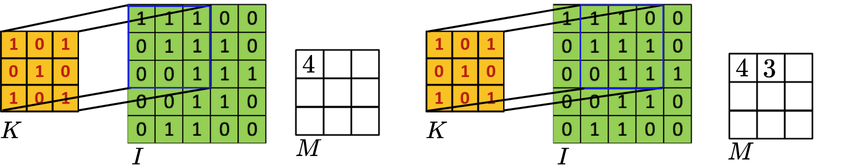

Wyjaśnienie symboli na obrazku
- $I$ - obrazek wejściowy
- $K$ - filtr (kernel) o wymiarze 3x3
- $M$ - wyjściowa mapa cech

Wynik przesuwania się filtra po wejściowej mapie można opisać wzorem

$$(K ⋆ I)(i, j) = \sum_{a=0}^{H_k-1}\sum_{b=0}^{W_k-1} K(a, b)I(i + a, j + b)$$

opisuje to jaki będzie wynik w pikselu o współrzędnych (i, j) w wynikowej mapie $M$. $H_k$ i $W_k$ oznaczają odpowiednio wysokość i szerokość filtra - często rozważamy kwadratowe rozmiary, $H_k$ = $W_k$.


(Tak naprawdę wzór wyżej opisuje korelację wzajemną - *cross-correlation*, ponieważ matematyczna operacja konwolucji dałaby wynik obrócony o 180 stopni)

Taka prosta formulacja nie uwzględnia faktu, że obrazki (zwykle) zawierają kanał koloru RGB. W takim razie filtr $K$ ma teraz możliwe współrzędne $K_{a,b,d}$. Wiemy już z poprzednich list, że budująć sieć neuronową chcemy zwiększyć liczbę ukrytych wymiarów. Dlatego też, aby zwiększyć liczbę kanałów z 3 (rgb) na $Q_k$, nasz filtr musi mieć 4 wymiary, więc indeksować się jako $K_{a,b,d,q}$. To oznacza, że mamy $Q_k$ pojedynczych filtrów, które będą przesuwać się po wejściowym obrazku. Ostatecznie konwolucja będzie mieć postać

$$M_{i,j,q} = \sum_{a=0}^{H_k-1}\sum_{b=0}^{W_k-1}\sum_{d=0}^{D_I-1}K(a, b, d, q)I(i + a, j + b, d)$$

Wynikowy rozmiar takiej mapy nie jest domyślnie równy wejściowemu obrazkowi (lub mapie). Wynika to z tego, że musimy wybrać tylko te "kawałki" obrazka, które w pełni mieszczą się w filtrze (później powiemy o paddingu). Zakładając, że obrazki są mają wymiar $H_I \times W_I \times D_I$, kernel $H_k \times W_k \times D_I \times Q_k$ to wynikowy rozmiar ma postać $$(H_I - H_k + 1) \times (W_I - W_k + 1) \times Q_k$$

Przesuwając kolejno filtr o jedną pozycję (jak dalej się dowiemy, krok jaki wykonuje filtr odnosi się do parametru *stride*) obliczamy wynikową mapę. Wartości w mapie $W$ nie są zwykle z góry znane (tym bardziej nie są binarne jak w prostym przykładzie wyżej), ale wyuczane w procesie trenowania sieci.


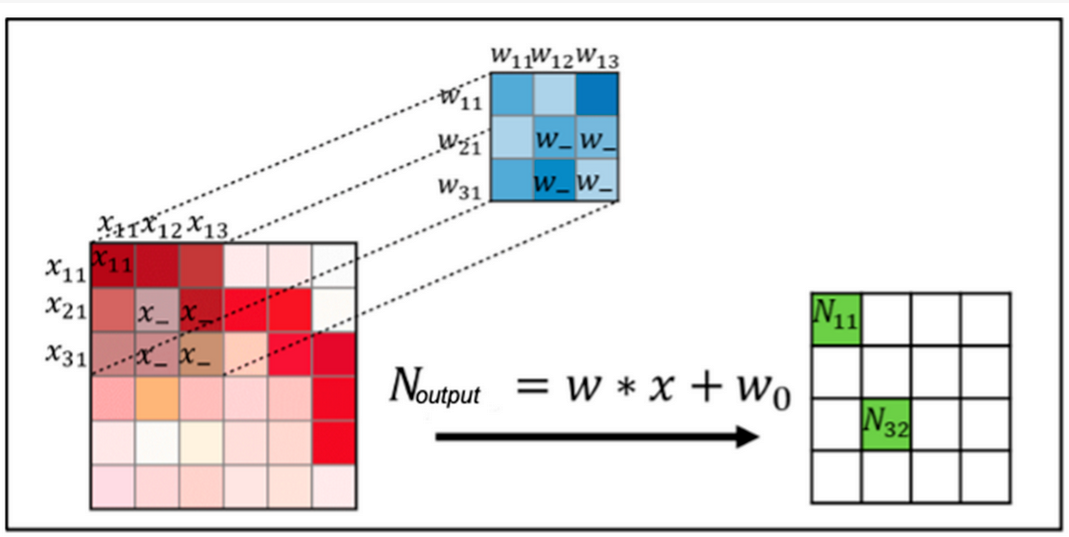

Polecam zajrzeć tutaj po interaktywną wizualizację https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks

### Zadanie 1
Bazując na opisie wyżej i wiarygodnych źródłach, napisz własną implementację operacji konwolucji. Może ona opierać się na macierzach NumPy lub PyTorch. Wykorzystaj poniższą linijkę z testami, aby sprawdzić swoje rozwiązanie.

Ekstra: pomyśl, czy dałoby się zapisać taką operację czysto w sposób macierzowy, pozbywając się pętli (lub chociaż ograniczając ich liczbę).

*Ekstra: pomyśl o dodaniu paddingu (może być to wartość 0), aby mapa wyjściowa była równa rozmiarowo wejściu (wtedy też musisz zmienić padding w testach).

In [ ]:
def convolution(X, K, q: int):
  '''
  Wykonuje operację konwolucji na wejściowym obrazie *X* oraz filtrze *K*. Zwraca wynikową mapę.
  Args:
    X: numpy / torch tensor o wymiarach (h, w, d)
    K: numpy / torch tensor o wymiarach (k, k, d, q)
    q: liczba filtrów
  '''


  h_in, w_in, d_in = X.shape
  k_h, k_w, d_out, _ = K.shape

  #w teorii k_q = q jako arg


  h_out=h_in-k_h+1
  w_out=w_in-k_w+1

  out_matrix=np.zeros((h_out,w_out,q), dtype=float)
  for q_s in range(q):
    current_filter = K[:, :, :, q_s]
    for i in range(h_out):
      for j in range(w_out):
        out_matrix[i,j,q_s]= np.sum( X[i:i+k_h, j:j+k_w,:]*current_filter) #domyslnie by bylo X[i:i+k_h, j:j+k_w,d], ale i tak w petli robimy sume, wiec mozna dodac cale d

  return out_matrix


#### Przypadki testowe
Nie musisz nic tutaj modyfikować z wyjątkiem gdy używasz NumPy (w kodzie są zaznaczone linijki, które trzeba odkomentować)

In [ ]:
def generate_deterministic_tensor(shape, mod_val=5, offset=0):
    count = 1
    for s in shape:
        count *= s
    # Tworzymy sekwencję 0, 1, 2... i bierzemy modulo
    data = torch.arange(count).float() % mod_val + offset
    return data.reshape(shape)

def torch_2_numpy(pt):
  return pt.detach().numpy()

def run_pytorch_test(case_name, img_hwc, kernel_hwcn):
    image_hwc = generate_deterministic_tensor(img_hwc, mod_val=5)
    kernel_hwcn = generate_deterministic_tensor(kernel_hwcn, mod_val=3, offset=-1)

    print(f"Input shape (H,W,C): {tuple(image_hwc.shape)}")
    print(f"Kernel shape (H,W,Cin,Cout): {tuple(kernel_hwcn.shape)}")

    # Dodanie wymiaru batcha
    input_tensor = image_hwc.permute(2, 0, 1).unsqueeze(0)
    weights = kernel_hwcn.permute(3, 2, 0, 1)
    output_tensor = F.conv2d(input_tensor, weights, stride=1, padding=0)
    output_hwc = output_tensor.squeeze(0).permute(1, 2, 0)

    # ODKOMENTUJ JEŚLI twoim inputem jest wielowymiarowa macierz NumPy
    image_hwc = torch_2_numpy(image_hwc)
    kernel_hwcn = torch_2_numpy(kernel_hwcn)

    my_output = convolution(image_hwc, kernel_hwcn, kernel_hwcn.shape[-1])
    if isinstance(my_output, np.ndarray):
        my_output = torch.from_numpy(my_output)

    my_output = my_output.to(torch.float64)
    output_hwc = output_hwc.to(torch.float64) # do samego typu żeby nie było błędu

    try:
      torch.testing.assert_close(my_output, output_hwc, rtol=1e-05, atol=1e-08)
      print(f"Test zaliczony")
    except AssertionError as e:
      print(f"Test niezaliczony: {e}")
    print(f"Output shape (H,W,C): {tuple(output_hwc.shape)}")

# --- URUCHOMIENIE PRZYPADKÓW ---

# Przypadek 1: Mały
run_pytorch_test("PRZYPADEK 1", (6, 6, 3), (3, 3, 3, 5))

# Przypadek 2: Średni
run_pytorch_test("PRZYPADEK 2", (12, 12, 3), (3, 3, 3, 5))

# Przypadek 3: Projekcja 1x1
run_pytorch_test("PRZYPADEK 3", (24, 24, 3), (1, 1, 3, 10))

Input shape (H,W,C): (6, 6, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (4, 4, 5)
Input shape (H,W,C): (12, 12, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (10, 10, 5)
Input shape (H,W,C): (24, 24, 3)
Kernel shape (H,W,Cin,Cout): (1, 1, 3, 10)
Test zaliczony
Output shape (H,W,C): (24, 24, 10)


Let's gooooooooo

### 2. Porównanie konwolucji i sieci w pełni połączonej

| Cecha | Konwolucja (CNN) | Sieć w pełni połączona (FNN / Dense) |
| :--- | :--- | :--- |
| **1. Wagi/Parametry** | **Współdzielone (Parameter Sharing)**<br>Ten sam zestaw wag (filtr) jest używany do skanowania całego obrazu | **Indywidualne**<br>Każde połączenie ma własną wagę przypisaną do konkretnego piksela/pozycji na wejściu |
| **2. Zasięg działania** | **Lokalny**<br>Operacja dotyczy tylko małego wycinka (okna) wokół aktualnie przetwarzanego punktu | **Globalny**<br>Każdy neuron w warstwie ukrytej "widzi" i jest połączony ze wszystkimi pikselami obrazu wejściowego |
| **3. Przesunięcie obiektu** | **Ekwiwariancja na translację**<br>Jeśli obiekt (np. kot) przesunie się na obrazie, sieć nadal go wykryje (tylko w innym miejscu mapy cech) | **Wrażliwość na pozycję**<br>Sieć musi "nauczyć się" wyglądu kota w każdym możliwym położeniu osobno, traktując je jako zupełnie nowe wzorce |
| **Efektywność** | Mniejsza liczba parametrów (dzięki współdzieleniu wag), szybsze uczenie obrazów | Ogromna liczba parametrów przy dużych obrazach, wysokie ryzyko przeuczenia |

### 3. Pole recepcyjne

Po angielsku *receptive field* odnosi się do wszystkich możliwych miejsc na obrazku, jak i na poprzednich mapach, które mogą wpływać na wynik w aktualnie rozważanym elemencie. Lepiej to obrazuje załączony schemat, gdzie widzimy jak element po środku tak naprawdę posiada informacje z poprzednich warstw. Jest to główna koncepcja w kontekście projektowania architektur konwolucyjnych sieci neuronowych, gdzie głębsze warstwy uczą się bardziej skomplikowanych struktur bazując na prymitywnych kształtach zidentyfikowanych na niższych warstwach.

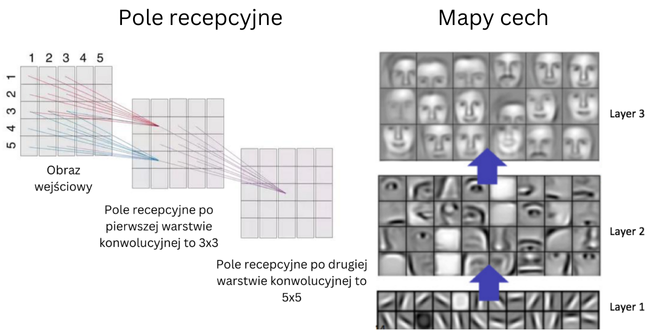

### 4. Operacja Poolingu

Aby jeszcze bardziej zmniejszyć rozmiar wynikowej mapy (tj. jej szerokość i wysokość) stosuje się operacje *max* lub *avg* pooling. Działają one w ten sposób, że na każdym rozłącznym kawałku wejściowego obrazka/mapy wykonujemy pewną redukcję do jednej wartości wyjściowej. Przypomina to operację konwolucji, natomiast nie mamy tutaj żadnych wag kernela, tylko z góry deterministyczną operację. Zastosowanie poolingu na kawałkach $2 \times 2$ zmniejsza wejściowy tensor dwukrotnie (dla $3 \times 3 $ zmniejszy trzykrotnie, i tak dalej). Zdecydowanie bardziej popularny jest **max pooling**, ponieważ przypomina wyciąganie tej najbardziej istotnej informacji z obrazka.

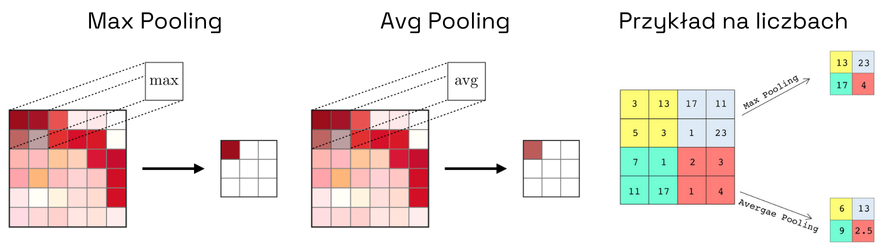

$$M(i, j) = \max_{(a, b) \in 𝒩} I(a, b) ← \text{max pooling} $$  
$$M(i, j) = \frac{1}{|𝒩|} \sum_{(a, b) \in 𝒩} I(a, b)  ← \text{avg pooling}$$

gdzie
- $I$ - wejściowy obrazek lub mapa
- $M$ - wyjściowa mapa
- $𝒩$ - fancy matematyczny znaczek na określenie sąsiedztwa, a w praktyce to zbiór wszystkich pozycji na wejściu $(a, b)$ które są aktualnie w rozważanym obszarze $n \times n$

#### Global Average Pooling

Ważną operacją bezpośrednio przydatną gdy będziemy implementować sieć CNN jest ekstremalna wersja poolingu, która przyjmuje mapę o wymiarze $H \times W \times C$ i zwraca wektor o długości $C$ (Tj. dla każdego kanału $c$ oblicza średnią po $H$ i $W$). Zwykle ta warstwa stanowi pomost między częścią konwolucyjną sieci a częścią w pełni połączoną (FFN).

### 5. Warstwa konwolucji w PyTorch
Zanim zaczniemy budować sieć składającą się z wielu warstw konwolucji, to warto zrozumieć jakie przyjmuje ona (najistotniejsze) parametry

```
class torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
```

- in_channels - liczba filtrów w wejściowej mapie/obrazku. Będzie to 3 dla obrazu RGB, a dla pośrednich map to będzie zależeć od liczby *out_channels* poprzedniej warstwy
- out_channels - liczba filtrów wyjściowych mapy (a jednocześnie liczba filtrów wejściowych do kolejnej warstwy konwolucyjnej)
- kernel_size - tuple (wysokość, szerokość) lub skalar dla kwadratowego filtra, od tej wielkości zależy też wysokość i szerokość wynikowej mapy
- stride - domyślnie 1, określa o ile pikseli przesuwamy się filtrem w każdym kolejnym kroku. Wybranie wartości > 1 ma podobny wpływ jak zastosowanie poolingu
- padding - domyślnie brak, określa jaka jest szerokość ramki, która jest dodawana do wejściowej mapy. Jest to przydatne kiedy chcemy, żeby wielkość wynikowej mapy była równa mapie wejściowej - wtedy podajemy jako wartość 'same' (tylko dla $stride = 1$)
- dilation - domyślnie 1, określa w obrębie samego filtra jaki jest odstęp między pikselami mapy wejściowej
- bias - oznacza to samo co dla warstwy liniowej, może być konieczne ustawienie na *False*

`kernel_size`, `stride`, `padding` i `dilation` mogą być typu `int` dla kwadratowych obszarów, lub `tuple` do określenia oddzielnie wysokości i szerokości

Wzór na wysokość ($H$) i szerokość ($W$) wyjściową ma postać
$$H_{out} = ⌊ \frac{H_{in} + 2 \times padding[0] - dilation[0] \times (kernel\_size[0] - 1) - 1}{stride[0]} + 1⌋$$

$$W_{out} = ⌊ \frac{W_{in} + 2 \times padding[1] - dilation[1] \times (kernel\_size[1] - 1) - 1}{stride[1]} + 1⌋$$

(symbol "podłogi" $⌊$, $⌋$ oznacza zaokrąglenie w dół do liczby całkowitej)

dla kwadratowego wejścia i filtrów upraszcza się to do $H_{out} = W_{out}$



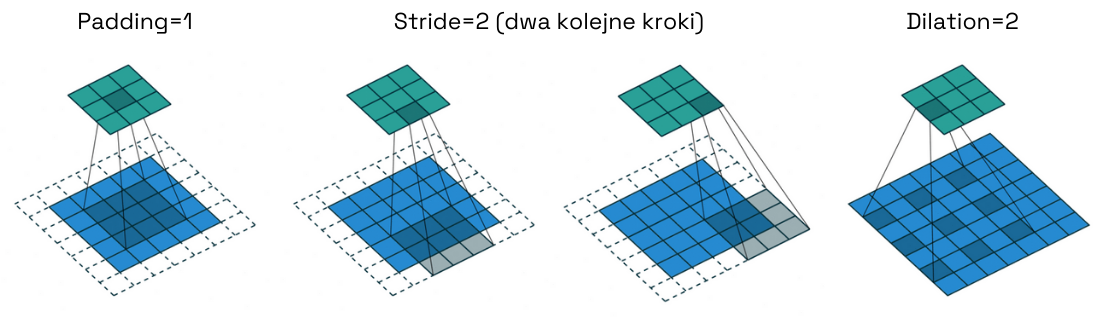

### Zadanie 2
Na podstawie wyżej wyjaśnionych argumentów i wzorów uzupełnij poniżej brakujące wartości. Nie musisz nad tym spędziać nie wiadomo ile czasu, ale warto nabrać intuicji które parametry musisz zmienić i jakie powinny być wartości by uzyskać zamierzoną wyjściową wielkość.

**Uwaga** zgodnie z konwencją Pytorcha, kolejność wymiarów po kolei to ($B$, $D$, $H$, $W$), tak więc wymiar kanału znajduje się nie na końcu, lecz na początku każdego obrazka/mapy. $B$ to batch size równy 1 tutaj.

In [ ]:
def validate_layer(case_name, layer, input_shape, expected_shape):
    print(f"--- {case_name} ---")
    print(f"Input: {input_shape}")

    # Tworzymy losowy tensor z batch=1
    x = torch.randn(1, *input_shape)

    try:
        y = layer(x)
        out_shape = tuple(y.shape)[1:] # bez batch

        print(f"Oczekiwany kształt: {expected_shape}")
        print(f"Twój kształt:       {out_shape}")

        if out_shape == expected_shape:
            print("OK. \n")
        else:
            print("Błąd: Kształty się nie zgadzają.\n")

    except Exception as e:
        print(f"Jakiś błąd: {e}\n")

# -------- TEST CASES ---------------

# PRZYPADEK 1: Agresywna redukcja (styl pierwszej warstwy AlexNet)
# Wejście: 224x224 (obraz)
# Wyjście: 55x55
# Wymagane: Użyj Padding=2. Resztę dobierz.
# Wskazówka: Kernel jest duży (>7), a krok (stride) też jest spory (>2).
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=11,  # <-- zmień to
    stride=4        # <-- zmień to

)


# Test 1
validate_layer("PRZYPADEK 1: Redukcja 224 -> 55", case_1,
                input_shape=(3, 224, 224),
                expected_shape=(64, 55, 55))

# PRZYPADEK 2: Asymetryczna konwolucja
# Wejście: 32x32
# Wyjście: 30x16
# Wymagane: Padding=0.
# Wskazówka: Wysokość (32->30) maleje wolno, Szerokość (32->16) maleje szybko.
# Użyj krotki (tuple) dla kernel_size i stride, np. (h, w).
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=(3, 2), # <-- zmień to
    stride=(1, 2)       # <-- zmień to
)

# Test 2
validate_layer("PRZYPADEK 2: Prostokątne okna 32 -> 30x16", case_2,
                input_shape=(1, 32, 32),
                expected_shape=(1, 30, 16))


# PRZYPADEK 3: "Dziurawy" Kernel (Dilated Convolution)
# Wejście: 50x50
# Wyjście: 46x46
# Wymagane: Stride=1, Padding=0. Kernel ma rozmiar 3x3.
# Zastanów się jak to możliwe, że kernel (3, 3) zmniejsza wielkość aż o 4 piksele?
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    # --- DO UZUPEŁNIENIA ---
    dilation=2  # <-- zmień to
)


# Test 3
validate_layer("PRZYPADEK 3: Dylatacja 50 -> 46", case_3,
                input_shape=(16, 50, 50),
                expected_shape=(16, 46, 46))

--- PRZYPADEK 1: Redukcja 224 -> 55 ---
Input: (3, 224, 224)
Oczekiwany kształt: (64, 55, 55)
Twój kształt:       (64, 55, 55)
OK. 

--- PRZYPADEK 2: Prostokątne okna 32 -> 30x16 ---
Input: (1, 32, 32)
Oczekiwany kształt: (1, 30, 16)
Twój kształt:       (1, 30, 16)
OK. 

--- PRZYPADEK 3: Dylatacja 50 -> 46 ---
Input: (16, 50, 50)
Oczekiwany kształt: (16, 46, 46)
Twój kształt:       (16, 46, 46)
OK. 



### 6. Architektura sieci konwolucyjnej

Głębokie sieci konwolucyjne składają się z warstw konwolucyjnych przeplatanych funkcjami aktywacji (zwykle ReLU), operacjami Poolingu, oraz odpowiednikami w 2D Batch Normalization i Dropout (niekoniecznie w tej kolejności). Wraz z kolejnymi warstwami powinna rosnąć liczba filtrów (np. 16 -> 32 -> 64 -> 128 itp.) i zmniejszać się wielkość każdej wynikowej mapy (filtry mają zwykle rozmiar 3x3).

Po serii takich warstw musimy znowu wrócić do w pełni połączonych warstw, z tego powodu stosujemy Global Average Pooling. Typowo taka architektura posłuży do zadania klasyfikacji.  



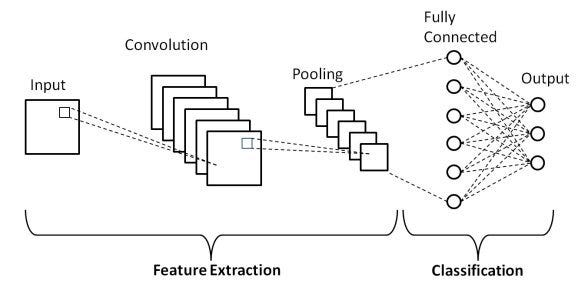

### Zadanie 3

**Zaimplementuj** i **wytrenuj** sieć konwolucyjną do zadania klasyfikacji dla zbioru FashionMNIST lub CIFAR10 (dowolność wyboru) która będzie zawierała następujące elementy
- co najmniej 2 bloki składające się z warstw konwolucyjnych i funkcji aktywacji
- sieci w pełni połączonej (minimalna głębokość to 1) służącej jako klasyfikator (powinno to być łatwe po poprzedniej liście)
- na tym etapie użyj [Flatten](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html) do spłaszczenia wymiarów $(B, C, H, W) → (B, C * H * W)$ dla wejścia do warswty liniowej

posłuży ona jako baseline do dalszych eksperymentów. Jeśli dysponujesz siecią FNN z poprzedniej listy, to możesz też odnieść się do jej wyników (nie musisz jej tutaj kopiować i na nowo trenować).

Przebieg trenowania dla sieci konwolucyjnej jest praktycznie taki sam jak do sieci z poprzedniego zadania, tylko że nie spłaszczamy obrazków na wejściu (m. in).

Przykładowy kod do pobrania danych (można go modyfikować):

```python
from torchvision import datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # lub użyjcie innej normalizacji jeśli uznacie za prawidłowe
  ])

trainset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
```
**Zwizualizuj** krzywe uczenia tak jak na poprzednich listach i odpowiednie metryki (np. *f1-score* lub *accuracy*)

In [6]:
from pathlib import Path


drive.mount('/content/drive')
base_path = Path('/content/drive/MyDrive/FashionMINST')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


trainset = datasets.FashionMNIST(
    root=base_path,
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root=base_path,
    train=False,
    download=True,
    transform=transform
)


Mounted at /content/drive


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 186kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.9MB/s]


In [7]:
customSEED=42

import torch
from torch.utils.data import DataLoader, random_split



np.random.seed(customSEED)
torch.manual_seed(customSEED)
torch.cuda.manual_seed_all(customSEED)

g = torch.Generator()
g.manual_seed(customSEED)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=g)


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

class TrainerTorch:
    def __init__(self,
                 model,
                 n_epochs=20,
                 batch_size=256,
                 lr=0.01,
                 patience=3,
                 optimizer: str = "SGD",
                 use_early_stopping: bool = False,
                 generator=None,
                 regularization: bool = False,
                 lambda_reg=0.01,
                 cosine_learning_rate: bool = False):

        self.model = model
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.optimizer_name = optimizer
        self.use_early_stopping = use_early_stopping
        self.generator = generator
        self.regularization = regularization
        self.cosine_learning_rate = cosine_learning_rate
        self.lambda_reg = lambda_reg

        self.lr_history = defaultdict(list)

        self.history = defaultdict(list)
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()

    def train(self, train_dataset, val_dataset):

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            generator=self.generator,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        print(f"Rozpoczynam trening na: {self.device}")

        weight_decay = self.lambda_reg if self.regularization else 0.0

        if self.optimizer_name == "SGD":
            optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)

        if self.cosine_learning_rate:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_epochs)

        for epoch in range(self.n_epochs):
            self.model.train()

            epoch_loss = 0.0
            epoch_correct = 0
            total_samples = 0 #zeby nie leciec przez caly zbior potem w evaluate (20 epok zajelo 8min)

            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                output = self.model(X)
                loss = self.criterion(output, y)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * X.size(0)
                predicted = output.argmax(dim=1)
                epoch_correct += (predicted == y).sum().item()
                total_samples += y.size(0)

            if self.cosine_learning_rate:
                scheduler.step()
                print(scheduler.get_lr())
                self.lr_history['lr'].append(scheduler.get_last_lr())

            train_l = epoch_loss / total_samples
            train_acc = epoch_correct / total_samples

            self.model.eval()
            with torch.no_grad():
                val_l, val_acc, _ = self.evaluate(val_loader)

                self.history['train_loss'].append(train_l)
                self.history['val_loss'].append(val_l)
                self.history['train_acc'].append(train_acc)
                self.history['val_acc'].append(val_acc)

                print(f"Epoch {epoch+1}/{self.n_epochs} | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_acc:.4f}")

                if val_l < self.best_val_loss:
                    self.best_val_loss = val_l
                    self.early_stop_counter = 0
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': self.model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': val_l,
                    }, 'checkpoint.pt')
                else:
                    self.early_stop_counter += 1

                if self.use_early_stopping and self.early_stop_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        self.plot_history()
        checkpoint = torch.load('checkpoint.pt', weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])

    def evaluate(self, loader):
        losses, accs = [], []
        all_preds = []

        for X, y in loader:
            X, y = X.to(self.device), y.to(self.device)
            A = self.model(X)
            loss = self.criterion(A, y)
            losses.append(loss.item())

            predicted_classes = A.argmax(dim=1)

            acc = (predicted_classes == y).float().mean().item()

            accs.append(acc)

            all_preds.append(A)
        full_preds = torch.cat(all_preds) if all_preds else None

        return np.mean(losses), np.mean(accs), full_preds


    def predict(self, x_test):
        test_loader = DataLoader(
            x_test,
            batch_size=self.batch_size,
            shuffle=False,
            generator=self.generator
        )
        self.model.eval()
        with torch.no_grad():
          loss, acc, A = self.evaluate(test_loader)
          print("Loss: "+str(loss))
          print("Acc: "+str(acc))
          return A


    def plot_history(self):
      epochs = range(1, len(self.history['train_loss']) + 1)

      plt.figure(figsize=(16, 5))

      plt.subplot(1, 2, 1)
      plt.plot(epochs, self.history['train_loss'], label='Train Loss')
      plt.plot(epochs, self.history['val_loss'], label='Val Loss')
      plt.title('Training and Validation Loss')
      plt.xlabel('Epochs')
      plt.ylabel('Loss')
      plt.legend()
      plt.grid(True)

      plt.subplot(1, 2, 2)
      plt.plot(epochs, self.history['train_acc'], label='Train Acc')
      plt.plot(epochs, self.history['val_acc'], label='Val Acc')
      plt.title('Training and Validation Accuracy')
      plt.xlabel('Epochs')
      plt.ylabel('Accuracy')
      plt.legend()
      plt.grid(True)

      plt.tight_layout()
      plt.show()

In [9]:
class ParametrizedCNN(nn.Module):
  def __init__(self, output_size, input_channels, input_size, batch_norm, pooling=None, extra_layer=False, stride=1, padding=1, dilation=1, use_gap=False):
    super().__init__()
    self.pooling = pooling
    self.batch_norm = batch_norm
    self.extra_layer = extra_layer
    self.use_gap = use_gap

    self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, stride=stride, padding=padding, dilation=dilation)
    self.activation1 = nn.ReLU()
    if batch_norm:
      self.batch_norm1 = nn.BatchNorm2d(16)
    if pooling == "avg":
      self.pooling1 = nn.AvgPool2d(2)
    elif pooling == "max":
      self.pooling1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=stride, padding=padding, dilation=dilation)
    self.activation2 = nn.ReLU()
    if batch_norm:
      self.batch_norm2 = nn.BatchNorm2d(32)
    if pooling == "avg":
      self.pooling2 = nn.AvgPool2d(2)
    elif pooling == "max":
      self.pooling2 = nn.MaxPool2d(2)

    if extra_layer:
      self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=stride, padding=padding, dilation=dilation)
      self.activation3 = nn.ReLU()
      if batch_norm:
        self.batch_norm3 = nn.BatchNorm2d(64)
      if pooling == "avg":
        self.pooling3 = nn.AvgPool2d(2)
      elif pooling == "max":
        self.pooling3 = nn.MaxPool2d(2)

    if use_gap:
      self.gap = nn.AdaptiveAvgPool2d(1)

    self.flatten = nn.Flatten()

    last_channels = 64 if extra_layer else 32

    if use_gap:
      linear_size = last_channels
    else:
      def get_size(s, k=3, p=padding, st=stride, d=dilation):
        return (s + 2*p - d*(k-1) - 1) // st + 1

      curr_size = input_size
      curr_size = get_size(curr_size)
      if pooling: curr_size //= 2
      curr_size = get_size(curr_size)
      if pooling: curr_size //= 2
      if extra_layer:
        curr_size = get_size(curr_size)
        if pooling: curr_size //= 2
      linear_size = last_channels * curr_size * curr_size

    self.fc = nn.Linear(linear_size, output_size)

  def forward(self, x):
    x = self.conv1(x)
    if self.batch_norm: x = self.batch_norm1(x)
    x = self.activation1(x)
    if self.pooling: x = self.pooling1(x)

    x = self.conv2(x)
    if self.batch_norm: x = self.batch_norm2(x)
    x = self.activation2(x)
    if self.pooling: x = self.pooling2(x)

    if self.extra_layer:
      x = self.conv3(x)
      if self.batch_norm: x = self.batch_norm3(x)
      x = self.activation3(x)
      if self.pooling: x = self.pooling3(x)

    if self.use_gap:
      x = self.gap(x)

    x = self.flatten(x)
    return self.fc(x)

Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 0.8777 | Val Loss: 0.6422 | Val Acc: 0.7638
Epoch 2/10 | Train Loss: 0.5688 | Val Loss: 0.5559 | Val Acc: 0.7902
Epoch 3/10 | Train Loss: 0.5067 | Val Loss: 0.4799 | Val Acc: 0.8338
Epoch 4/10 | Train Loss: 0.4710 | Val Loss: 0.5916 | Val Acc: 0.7989
Epoch 5/10 | Train Loss: 0.4506 | Val Loss: 0.4639 | Val Acc: 0.8367
Epoch 6/10 | Train Loss: 0.4293 | Val Loss: 0.4421 | Val Acc: 0.8475
Epoch 7/10 | Train Loss: 0.4159 | Val Loss: 0.4254 | Val Acc: 0.8519
Epoch 8/10 | Train Loss: 0.4003 | Val Loss: 0.4357 | Val Acc: 0.8517
Epoch 9/10 | Train Loss: 0.3936 | Val Loss: 0.4091 | Val Acc: 0.8586
Epoch 10/10 | Train Loss: 0.3842 | Val Loss: 0.4081 | Val Acc: 0.8606


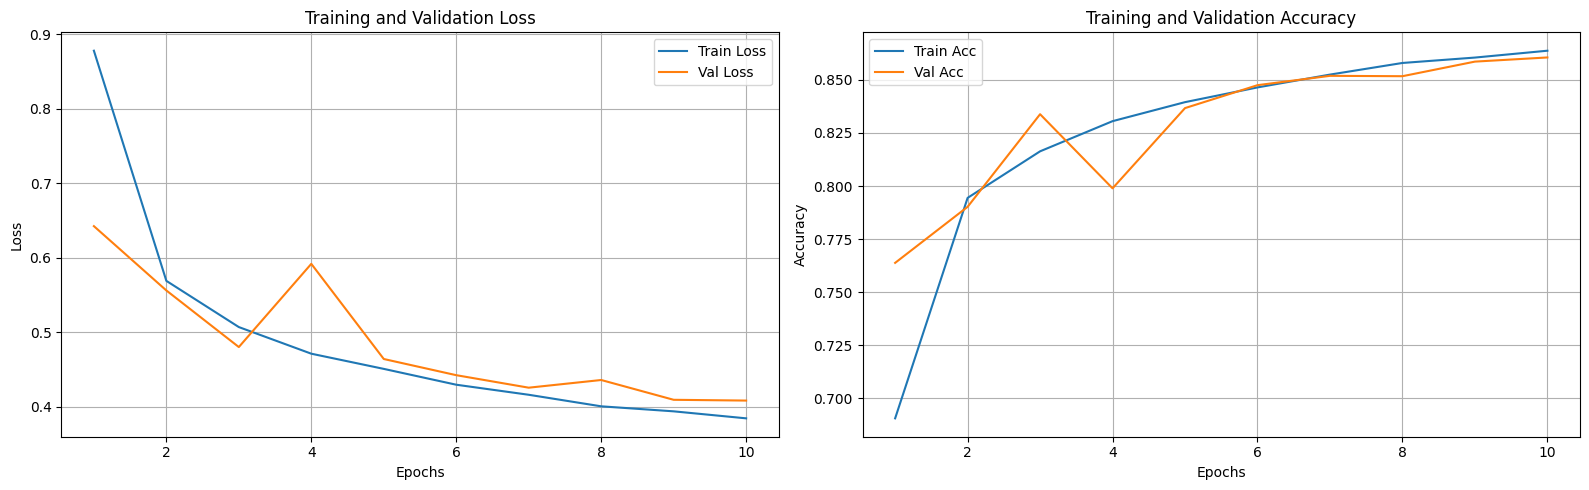

Loss: 0.4207459084689617
Acc: 0.85029296875


tensor([[-4.4006, -6.1877, -2.6252,  ...,  6.2098,  2.8680,  7.6188],
        [ 1.4796, -0.3986,  9.7267,  ..., -9.9606,  1.0501, -6.8895],
        [ 1.1240, 14.1026,  0.2959,  ..., -1.2099,  0.1198, -7.2528],
        ...,
        [ 2.0000, -5.4504,  0.4973,  ..., -1.4970,  6.4656, -6.5275],
        [-1.9993, 10.5444, -0.5638,  ..., -0.7526, -0.9033, -2.8317],
        [-3.0383, -3.8859, -0.7681,  ...,  3.9104,  2.3718, -0.0417]],
       device='cuda:0')

In [10]:
model_baseline = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                            batch_norm=False)
trainer_max = TrainerTorch(model_baseline, n_epochs=10, generator=g)
trainer_max.train(train_subset, val_subset)
summary(model_baseline, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)
trainer_max.predict(testset)

Nawet niezły baseline

### Zadanie 4

Przeprowadź następujące eksperymenty:

- Eksperyment 1: Dodaj *Max Pooling* w odpowiednim miejscu po warstwach konwolucyjnych. Porównaj z działaniem *Average Pooling*.

- Eksperyment 2: Dodaj warstwę *Global Average Pooling* zamiast spłaszczania tensora przy pomocy Flatten. (Bazuj na sieci z eksperymentu 1)

- Eksperyment 3: Dodaj *Batch Normalization* i/lub *Dropout* w wersji dla 2D. (Bazuj na sieci z eksperymentu 2 z Max Poolingiem)

- Eksperyment 4: Zwiększ liczbę warstw konwolucyjnych i odpowiednio dobierz liczbę filtrów. (Bazuj na sieci z eksperymentu 3)

- Eksperyment 5: Zmień co najmniej 2 wartości domyślne parametrów z listy: `stride`, `dilation`, `padding`. Dlaczego wybrałeś/aś takie parametry i jak poskutkowało ich dodanie? (np. sieć jest mniejsza; wynikowa mapa przed global avg pooling jest mniejsza;)

Po każdej nowej wersji modelu zbadaj jego wielkość

```
summary(model, input_size=(1, 3, 32, 32)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)
```

Pamiętaj, żeby nie pisać na nowo (bądź kopiować) pętli do trenowania - zwiększy to czytelność notebooka. Również może być pomocna parametryzacja modelu zamiast tworzenie nowej klasy dla każdego eksperymentu z osobna ([ModuleList](https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html) łączy warstwy w liście wejściowej). **Udokumentuj przebieg eksperymentów** w postaci porównania wybranych metryk i/lub krzywych uczenia.


Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 1.3645 | Val Loss: 0.8458 | Val Acc: 0.6713
Epoch 2/10 | Train Loss: 0.7264 | Val Loss: 0.7083 | Val Acc: 0.7362
Epoch 3/10 | Train Loss: 0.6498 | Val Loss: 0.6093 | Val Acc: 0.7843
Epoch 4/10 | Train Loss: 0.5998 | Val Loss: 0.6750 | Val Acc: 0.7736
Epoch 5/10 | Train Loss: 0.5690 | Val Loss: 0.5780 | Val Acc: 0.7938
Epoch 6/10 | Train Loss: 0.5368 | Val Loss: 0.5470 | Val Acc: 0.8045
Epoch 7/10 | Train Loss: 0.5128 | Val Loss: 0.5281 | Val Acc: 0.8065
Epoch 8/10 | Train Loss: 0.4891 | Val Loss: 0.5661 | Val Acc: 0.8042
Epoch 9/10 | Train Loss: 0.4723 | Val Loss: 0.4820 | Val Acc: 0.8287
Epoch 10/10 | Train Loss: 0.4597 | Val Loss: 0.4992 | Val Acc: 0.8158


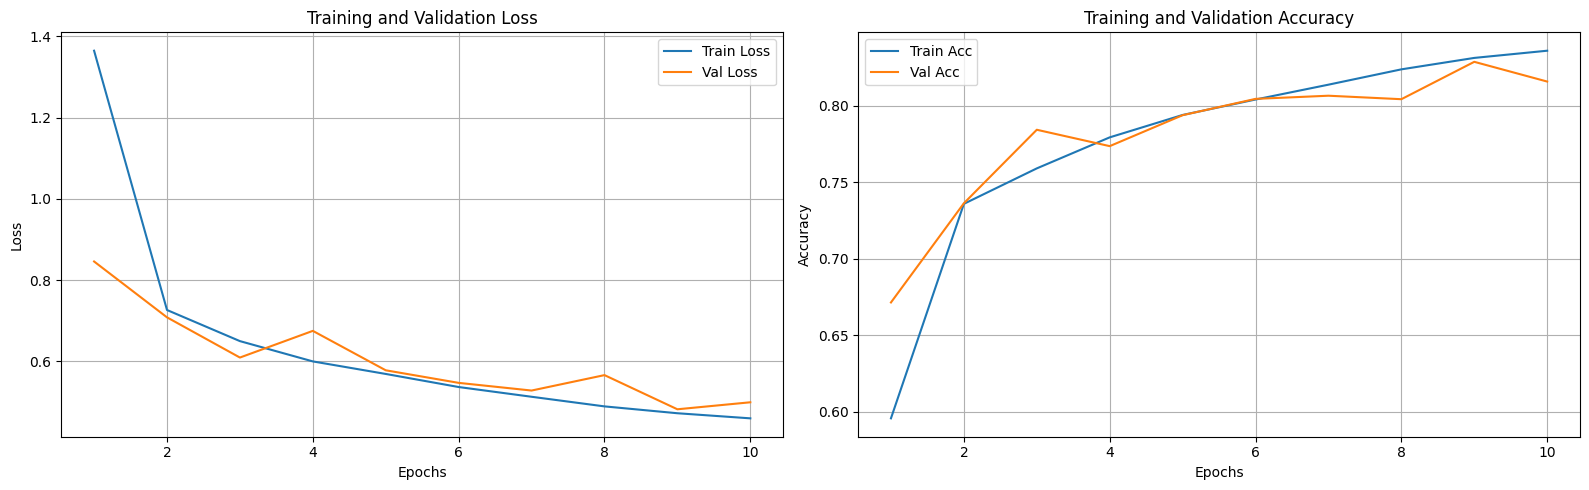

Loss: 0.48790798932313917
Acc: 0.82646484375


tensor([[-4.3505, -4.9827, -2.4000,  ...,  5.7024,  2.3331,  6.9636],
        [ 1.3320, -1.0211,  9.0304,  ..., -9.4540,  1.3794, -6.0487],
        [-0.7374, 14.1786, -2.9344,  ..., -5.4949, -0.5288, -4.8309],
        ...,
        [ 2.1472, -5.3607,  0.7614,  ..., -2.9979,  5.6168, -4.2789],
        [-1.5022,  8.5879, -2.0493,  ..., -3.0250, -1.6275, -2.0778],
        [-2.4457, -4.4008, -0.3061,  ...,  3.6714,  1.7481,  0.8429]],
       device='cuda:0')

In [ ]:
model_max = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                            batch_norm=False, pooling="max")
trainer_max = TrainerTorch(model_max, n_epochs=10, generator=g)
trainer_max.train(train_subset, val_subset)
summary(model_max, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)
trainer_max.predict(testset)

Accuracy mniejsze niz baseline, ciekawe

In [ ]:
summary(model_max, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)


Layer (type:depth-idx)                   Output Shape              Param #
ParametrizedCNN                          [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 16, 14, 14]           --
├─Conv2d: 1-4                            [1, 32, 14, 14]           4,640
├─ReLU: 1-5                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 32, 7, 7]             --
├─Flatten: 1-7                           [1, 1568]                 --
├─Linear: 1-8                            [1, 10]                   15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.08
Estimated Total Size (MB): 0.24

Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 1.5988 | Val Loss: 0.8582 | Val Acc: 0.6964
Epoch 2/10 | Train Loss: 0.7671 | Val Loss: 0.7640 | Val Acc: 0.7158
Epoch 3/10 | Train Loss: 0.7011 | Val Loss: 0.6937 | Val Acc: 0.7472
Epoch 4/10 | Train Loss: 0.6627 | Val Loss: 0.6672 | Val Acc: 0.7612
Epoch 5/10 | Train Loss: 0.6355 | Val Loss: 0.6416 | Val Acc: 0.7681
Epoch 6/10 | Train Loss: 0.6136 | Val Loss: 0.6566 | Val Acc: 0.7592
Epoch 7/10 | Train Loss: 0.6097 | Val Loss: 0.6450 | Val Acc: 0.7629
Epoch 8/10 | Train Loss: 0.5925 | Val Loss: 0.5835 | Val Acc: 0.7971
Epoch 9/10 | Train Loss: 0.5754 | Val Loss: 0.5763 | Val Acc: 0.7979
Epoch 10/10 | Train Loss: 0.5710 | Val Loss: 0.5798 | Val Acc: 0.7894


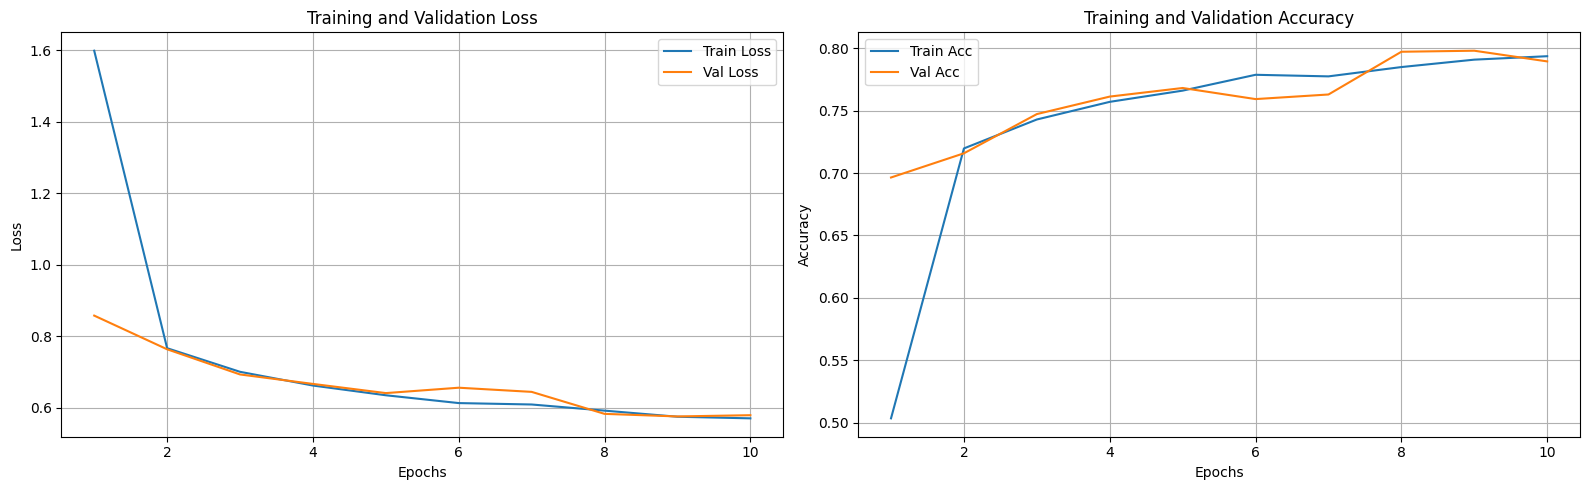

Loss: 0.5810462310910225
Acc: 0.7875


tensor([[ -5.3415, -10.9154,  -3.1009,  ...,   8.3272,   3.8874,   8.3323],
        [  1.2954,  -3.9000,   7.0636,  ...,  -6.4238,   0.6575,  -5.1305],
        [  2.6483,   9.3084,  -0.2220,  ...,  -3.0964,  -2.2422,  -7.3562],
        ...,
        [  3.0042,  -9.0869,   0.0241,  ...,  -1.3554,   6.3117,  -5.1542],
        [  0.9650,   6.9647,  -0.5344,  ...,  -1.9418,  -2.7930,  -4.7844],
        [ -2.9958,  -6.6405,  -1.1201,  ...,   4.7265,   2.9301,   1.2174]],
       device='cuda:0')

In [ ]:
model_avg = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                            batch_norm=False, pooling="avg")
trainer_avg = TrainerTorch(model_avg, n_epochs=10, generator=g)
trainer_avg.train(train_subset, val_subset)
summary(model_avg, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)
trainer_avg.predict(testset)

Tutaj tak samo

In [ ]:
summary(model_avg, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)


Layer (type:depth-idx)                   Output Shape              Param #
ParametrizedCNN                          [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─AvgPool2d: 1-3                         [1, 16, 14, 14]           --
├─Conv2d: 1-4                            [1, 32, 14, 14]           4,640
├─ReLU: 1-5                              [1, 32, 14, 14]           --
├─AvgPool2d: 1-6                         [1, 32, 7, 7]             --
├─Flatten: 1-7                           [1, 1568]                 --
├─Linear: 1-8                            [1, 10]                   15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.08
Estimated Total Size (MB): 0.24

Jak widać model z max pooling ma lepsze accuracy niż avg pooling

Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 2.1235 | Val Loss: 1.9832 | Val Acc: 0.3779
Epoch 2/10 | Train Loss: 1.8703 | Val Loss: 1.7686 | Val Acc: 0.4350
Epoch 3/10 | Train Loss: 1.6827 | Val Loss: 1.6100 | Val Acc: 0.4924
Epoch 4/10 | Train Loss: 1.5485 | Val Loss: 1.4967 | Val Acc: 0.5329
Epoch 5/10 | Train Loss: 1.4475 | Val Loss: 1.4096 | Val Acc: 0.5538
Epoch 6/10 | Train Loss: 1.3674 | Val Loss: 1.3397 | Val Acc: 0.5930
Epoch 7/10 | Train Loss: 1.3014 | Val Loss: 1.2783 | Val Acc: 0.6187
Epoch 8/10 | Train Loss: 1.2451 | Val Loss: 1.2259 | Val Acc: 0.6389
Epoch 9/10 | Train Loss: 1.1957 | Val Loss: 1.1791 | Val Acc: 0.6504
Epoch 10/10 | Train Loss: 1.1523 | Val Loss: 1.1381 | Val Acc: 0.6628


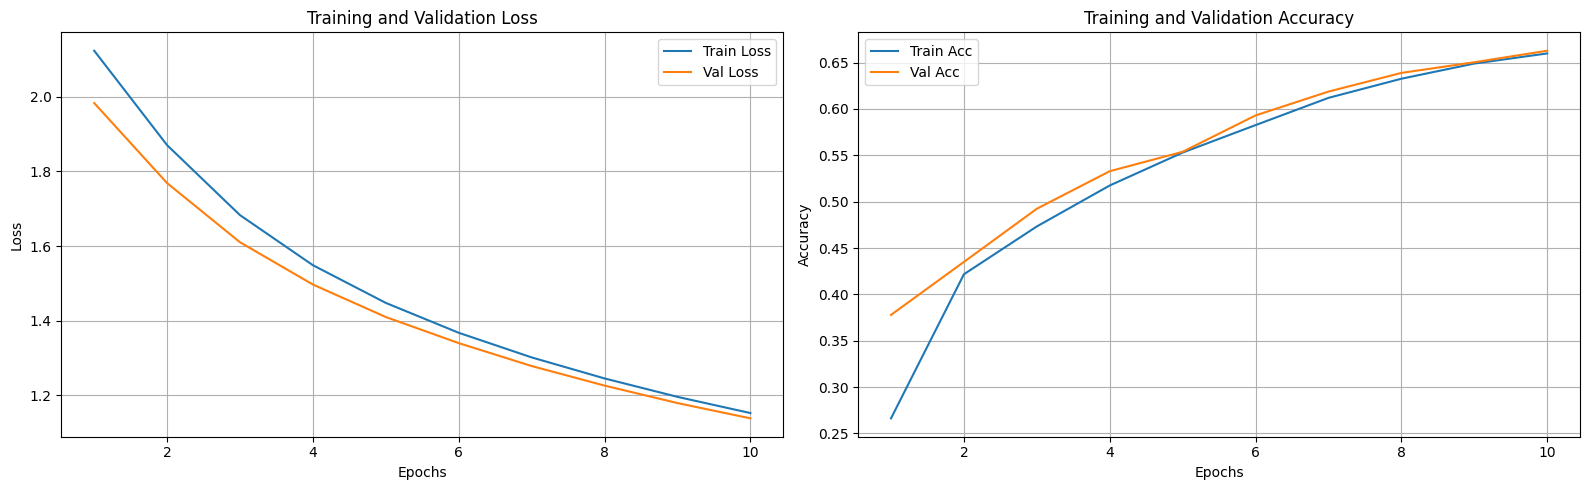

Loss: 1.1318792551755905
Acc: 0.6669921875


tensor([[-0.1042, -3.0243, -3.1302,  ...,  2.5298,  1.0682,  2.1319],
        [ 0.7994,  0.2550,  3.2491,  ..., -6.2689,  1.1397, -1.3363],
        [ 0.3415,  5.6686,  1.2400,  ..., -4.9580, -2.0224, -3.3773],
        ...,
        [ 0.4436,  0.3881, -2.0954,  ..., -0.0294, -0.6007, -0.6720],
        [ 0.3194,  4.4178,  0.5018,  ..., -3.3898, -1.9205, -2.7224],
        [ 0.3055, -1.8675, -2.3485,  ...,  1.7076,  0.4305,  0.7098]],
       device='cuda:0')

In [ ]:
model_bn = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                          batch_norm=True, pooling="max", use_gap=True)
trainer_bn = TrainerTorch(model_bn, n_epochs=10, generator=g)
trainer_bn.train(train_subset, val_subset)
summary(model_bn, input_size=(1, 1, 28, 28))
trainer_bn.predict(testset)

Modelowi z batchnorm dosyć słabo poszło, duży loss, chyba za szybko zatrzymany trening

In [ ]:
summary(model_bn, input_size=(1, 1, 28, 28)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)


Layer (type:depth-idx)                   Output Shape              Param #
ParametrizedCNN                          [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─MaxPool2d: 1-4                         [1, 16, 14, 14]           --
├─Conv2d: 1-5                            [1, 32, 14, 14]           4,640
├─BatchNorm2d: 1-6                       [1, 32, 14, 14]           64
├─ReLU: 1-7                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 32, 7, 7]             --
├─AdaptiveAvgPool2d: 1-9                 [1, 32, 1, 1]             --
├─Flatten: 1-10                          [1, 32]                   --
├─Linear: 1-11                           [1, 10]                   330
Total params: 5,226
Trainable params: 5,226
Non-trainable params: 0
Total mult-a

Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 1.6076 | Val Loss: 1.2460 | Val Acc: 0.7016
Epoch 2/10 | Train Loss: 1.0761 | Val Loss: 0.9492 | Val Acc: 0.7326
Epoch 3/10 | Train Loss: 0.8560 | Val Loss: 0.7983 | Val Acc: 0.7544
Epoch 4/10 | Train Loss: 0.7352 | Val Loss: 0.7028 | Val Acc: 0.7698
Epoch 5/10 | Train Loss: 0.6597 | Val Loss: 0.6414 | Val Acc: 0.7852
Epoch 6/10 | Train Loss: 0.6070 | Val Loss: 0.5981 | Val Acc: 0.7948
Epoch 7/10 | Train Loss: 0.5671 | Val Loss: 0.5685 | Val Acc: 0.8050
Epoch 8/10 | Train Loss: 0.5341 | Val Loss: 0.5450 | Val Acc: 0.8163
Epoch 9/10 | Train Loss: 0.5064 | Val Loss: 0.5049 | Val Acc: 0.8313
Epoch 10/10 | Train Loss: 0.4851 | Val Loss: 0.4821 | Val Acc: 0.8382


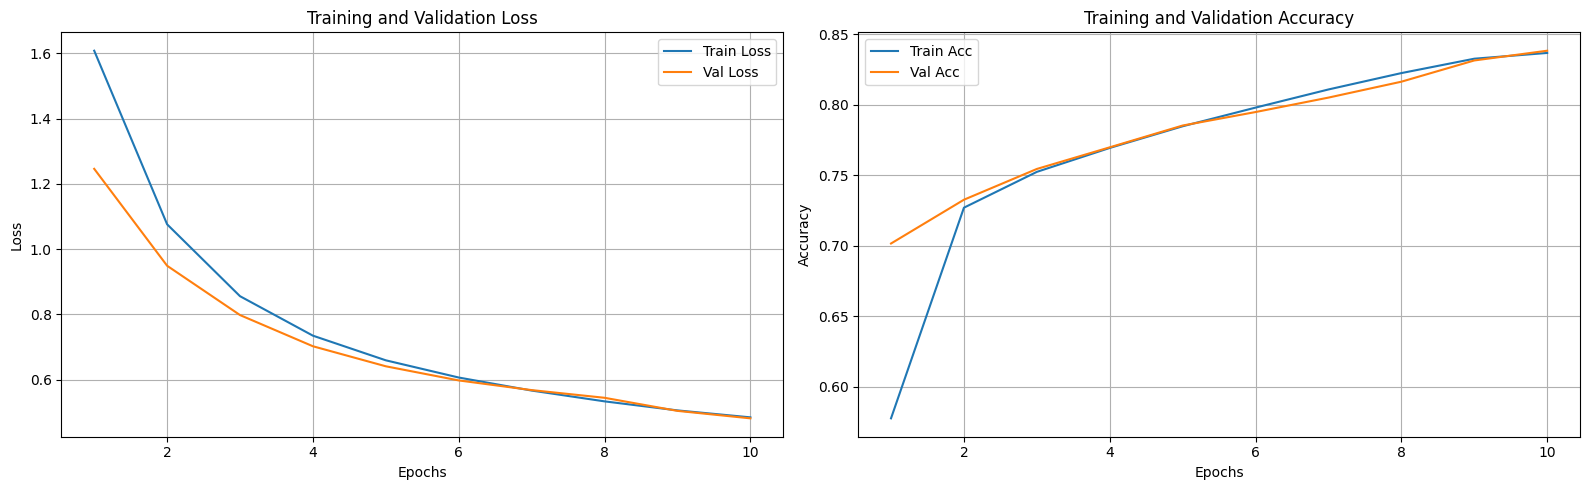

Loss: 0.4878313422203064
Acc: 0.8361328125


tensor([[-1.2397, -4.2090, -2.6636,  ...,  3.4732,  0.3745,  4.5863],
        [ 0.0215, -0.2766,  4.5631,  ..., -4.5600, -1.6702, -2.9378],
        [ 0.3355,  9.3696, -0.1723,  ..., -4.8017, -3.4131, -3.2696],
        ...,
        [ 0.9534, -2.8432, -1.3017,  ..., -3.2800,  4.6725, -2.5544],
        [-1.6728,  6.4904,  0.2431,  ..., -4.7082, -3.0722, -2.7107],
        [-0.2339, -3.1870, -0.9751,  ...,  3.0232,  0.4885,  0.6711]],
       device='cuda:0')

In [ ]:
model_deep = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                            batch_norm=True, pooling="max", extra_layer=True, use_gap=True)
trainer_deep = TrainerTorch(model_deep, n_epochs=10, generator=g)
trainer_deep.train(train_subset, val_subset)
summary(model_deep, input_size=(1, 1, 28, 28))
trainer_deep.predict(testset)

Tutaj wynik jest wyzszy niz baseline

In [ ]:
summary(model_deep, input_size=(1, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
ParametrizedCNN                          [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─MaxPool2d: 1-4                         [1, 16, 14, 14]           --
├─Conv2d: 1-5                            [1, 32, 14, 14]           4,640
├─BatchNorm2d: 1-6                       [1, 32, 14, 14]           64
├─ReLU: 1-7                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 32, 7, 7]             --
├─Conv2d: 1-9                            [1, 64, 7, 7]             18,496
├─BatchNorm2d: 1-10                      [1, 64, 7, 7]             128
├─ReLU: 1-11                             [1, 64, 7, 7]             --
├─MaxPool2d: 1-12                        [1, 64, 3, 3]             --
├─Adap

Zwiększyłem padding do 2, żeby sieć nie pomijała rogów obrazków oraz dilation=2, żeby miała większy "obraz"

Rozpoczynam trening na: cuda
Epoch 1/10 | Train Loss: 1.5580 | Val Loss: 1.1384 | Val Acc: 0.6927
Epoch 2/10 | Train Loss: 0.9592 | Val Loss: 0.8480 | Val Acc: 0.7294
Epoch 3/10 | Train Loss: 0.7691 | Val Loss: 0.7326 | Val Acc: 0.7464
Epoch 4/10 | Train Loss: 0.6799 | Val Loss: 0.6626 | Val Acc: 0.7632
Epoch 5/10 | Train Loss: 0.6247 | Val Loss: 0.6163 | Val Acc: 0.7780
Epoch 6/10 | Train Loss: 0.5825 | Val Loss: 0.5786 | Val Acc: 0.7900
Epoch 7/10 | Train Loss: 0.5486 | Val Loss: 0.5478 | Val Acc: 0.8033
Epoch 8/10 | Train Loss: 0.5204 | Val Loss: 0.5272 | Val Acc: 0.8078
Epoch 9/10 | Train Loss: 0.4967 | Val Loss: 0.4992 | Val Acc: 0.8251
Epoch 10/10 | Train Loss: 0.4757 | Val Loss: 0.4858 | Val Acc: 0.8281


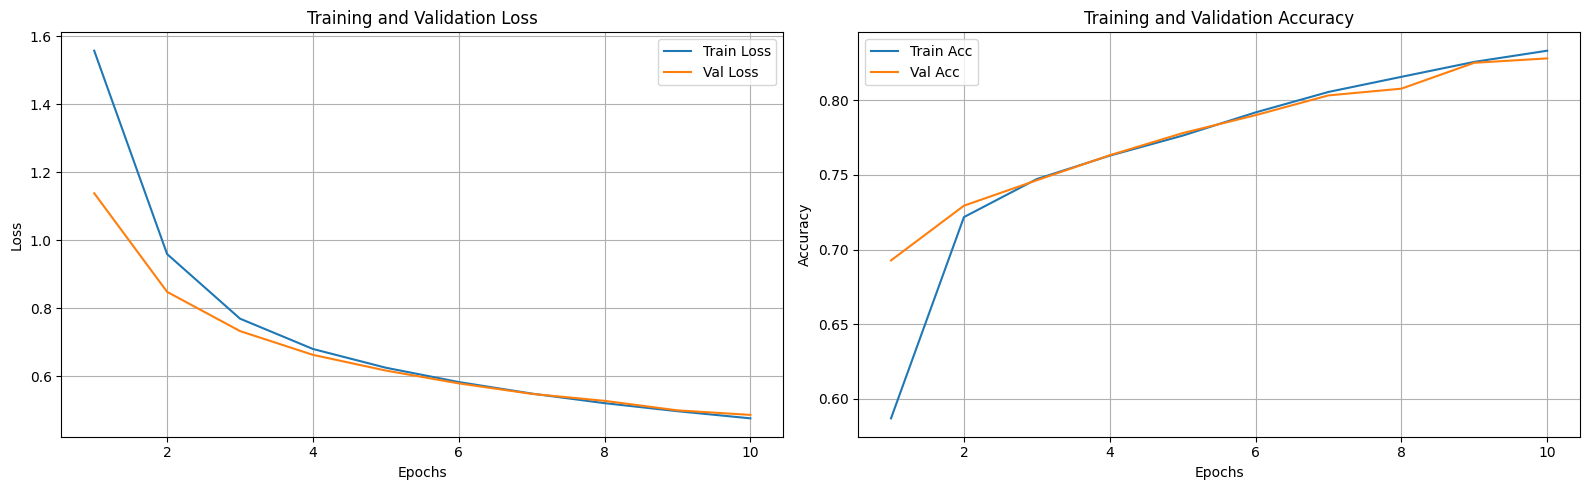

Loss: 0.4925512246787548
Acc: 0.82275390625


tensor([[-2.4048, -3.6553, -0.7848,  ...,  4.2310,  0.5067,  5.1880],
        [-0.0137, -0.2022,  4.8853,  ..., -2.6364,  0.0829, -1.5073],
        [-2.1222,  8.6336,  1.7252,  ..., -3.4006, -4.9791, -2.3936],
        ...,
        [ 1.4958, -3.0398, -0.7392,  ..., -1.5290,  3.9262, -2.5489],
        [-1.3056,  7.2119,  1.9438,  ..., -3.4020, -3.4075, -2.1167],
        [-0.7156, -3.7802, -1.0863,  ...,  4.3093,  0.7717,  1.3890]],
       device='cuda:0')

In [ ]:
model_custom = ParametrizedCNN(output_size=10, input_channels=1, input_size=28,
                            batch_norm=True, pooling="max", extra_layer=True, padding = 2, dilation=2, use_gap=True)
trainer_custom = TrainerTorch(model_custom, n_epochs=10, generator=g)
trainer_custom.train(train_subset, val_subset)
summary(model_custom, input_size=(1, 1, 28, 28))
trainer_custom.predict(testset)

Jak widac zmiany nie dały żadnej poprawy

In [ ]:
summary(model_custom, input_size=(1, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
ParametrizedCNN                          [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─BatchNorm2d: 1-2                       [1, 16, 28, 28]           32
├─ReLU: 1-3                              [1, 16, 28, 28]           --
├─MaxPool2d: 1-4                         [1, 16, 14, 14]           --
├─Conv2d: 1-5                            [1, 32, 14, 14]           4,640
├─BatchNorm2d: 1-6                       [1, 32, 14, 14]           64
├─ReLU: 1-7                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 32, 7, 7]             --
├─Conv2d: 1-9                            [1, 64, 7, 7]             18,496
├─BatchNorm2d: 1-10                      [1, 64, 7, 7]             128
├─ReLU: 1-11                             [1, 64, 7, 7]             --
├─MaxPool2d: 1-12                        [1, 64, 3, 3]             --
├─Adap

wnioski:

Spodziewałem się lepszych wyników, może gdzieś się wkadrł błąd.

Najlepsze accuracy miał w zasadzie model baseline oraz model z dodatkową warstwą, jednak nie różniły się mocno od siebie

### *Zadanie 5 (dla chętnych)

Wykorzystaj [CAM](https://zilliz.com/learn/class-activation-mapping-CAM) do wizualizacji aktywacji konwolucji dla kilku przykładów ze zbioru testowego. Do tego celu twoja sieć musi koniecznie mieć warstwę Global Avg Pooling, a końcowy moduł FNN być jednowarstwowy.